In [40]:
# Install required helper libraries if not already installed
%pip install openpyxl pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from your folder path
df = pd.read_excel('DryBeanDataset/Dry_Bean_Dataset.xlsx')

# 2. Inspect shape and structure
print("Dataset Shape:", df.shape)
display(df.head())

# 3. Check column types and missing values
print("\n--- Data Info ---")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dataset Shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: f

Dataset shape after dropping duplicates: (13543, 17)

--- Bean Class Distribution ---
DERMASON  :  3546 samples (26.18%)
SIRA      :  2636 samples (19.46%)
SEKER     :  2027 samples (14.97%)
HOROZ     :  1860 samples (13.73%)
CALI      :  1630 samples (12.04%)
BARBUNYA  :  1322 samples (9.76%)
BOMBAY    :   522 samples (3.85%)


C:\Users\Karthik\AppData\Local\Temp\ipykernel_16232\2209831135.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=class_counts.index, palette='viridis')


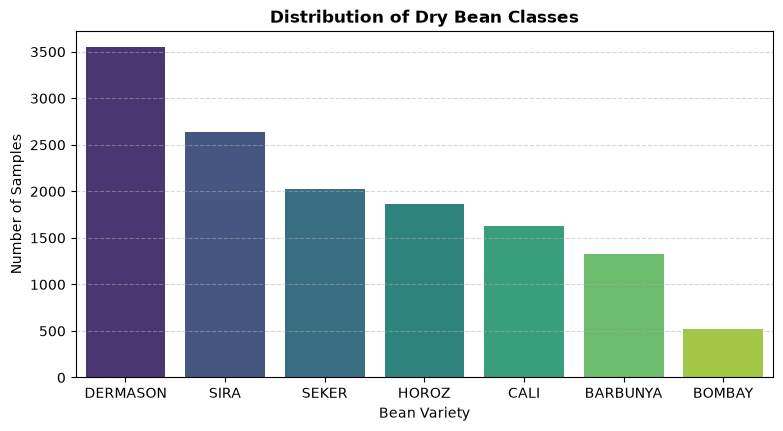

In [41]:
# 1. Remove duplicate rows
df = df.drop_duplicates()
print(f"Dataset shape after dropping duplicates: {df.shape}")

# 2. Check class distribution (count and percentage)
class_counts = df['Class'].value_counts()
class_percentage = df['Class'].value_counts(normalize=True) * 100

print("\n--- Bean Class Distribution ---")
for cls, count in class_counts.items():
    print(f"{cls:<10}: {count:>5} samples ({class_percentage[cls]:.2f}%)")

# 3. Plot class distribution bar chart
plt.figure(figsize=(9, 4.5))
sns.countplot(data=df, x='Class', order=class_counts.index, palette='viridis')
plt.title('Distribution of Dry Bean Classes', fontsize=12, fontweight='bold')
plt.xlabel('Bean Variety', fontsize=10)
plt.ylabel('Number of Samples', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

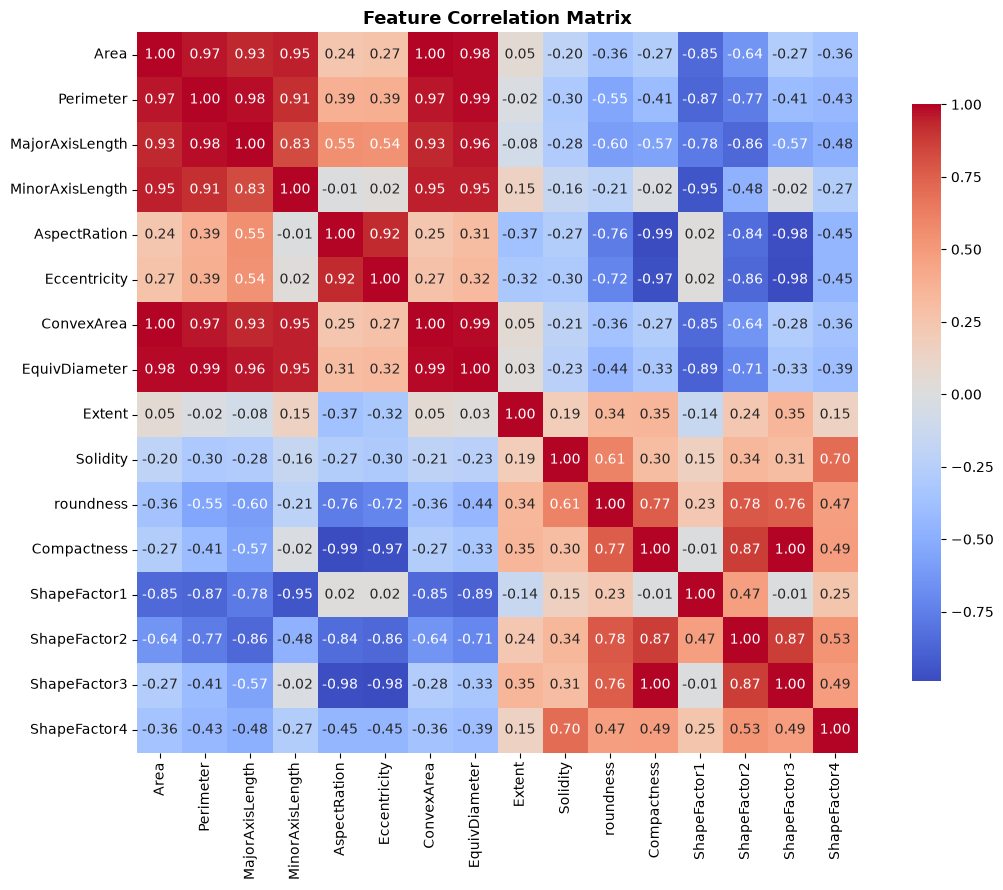

In [42]:
# Select numeric columns for correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target Label (y)
X = df.drop(columns=['Class'])
y = df['Class']

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Fit scaler ONLY on X_train to avoid data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 4. Verify shapes and scaling sanity
print("--- Data Splitting & Scaling Summary ---")
print(f"Training samples: {X_train_scaled.shape[0]} rows, {X_train_scaled.shape[1]} features")
print(f"Testing samples : {X_test_scaled.shape[0]} rows, {X_test_scaled.shape[1]} features")
print(f"\nMean of scaled X_train (should be ~0):\n{X_train_scaled.mean().round(2).to_dict()}")

--- Data Splitting & Scaling Summary ---
Training samples: 10834 rows, 16 features
Testing samples : 2709 rows, 16 features

Mean of scaled X_train (should be ~0):
{'Area': -0.0, 'Perimeter': 0.0, 'MajorAxisLength': -0.0, 'MinorAxisLength': -0.0, 'AspectRation': 0.0, 'Eccentricity': 0.0, 'ConvexArea': 0.0, 'EquivDiameter': -0.0, 'Extent': -0.0, 'Solidity': -0.0, 'roundness': -0.0, 'Compactness': 0.0, 'ShapeFactor1': -0.0, 'ShapeFactor2': 0.0, 'ShapeFactor3': 0.0, 'ShapeFactor4': -0.0}


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# 1. Initialize Baseline Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 2. Train and Evaluate Each Model
baseline_results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    baseline_results[name] = {"Accuracy": acc, "Weighted F1-Score": f1}
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Weighted F1-Score: {f1:.4f}\n")

# 3. Summary DataFrame for Deliverable 1 Report
df_baselines = pd.DataFrame(baseline_results).T
display(df_baselines)

=== Logistic Regression ===
Accuracy: 0.9192 | Weighted F1-Score: 0.9193

=== K-Nearest Neighbors ===
Accuracy: 0.9155 | Weighted F1-Score: 0.9157

=== Decision Tree ===
Accuracy: 0.8966 | Weighted F1-Score: 0.8964



,Accuracy,Weighted F1-Score
Logistic Regression,0.919158,0.919290
K-Nearest Neighbors,0.915467,0.915652
Decision Tree,0.896641,0.896412


C:\Users\Karthik\AppData\Local\Temp\ipykernel_16232\2409394290.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='magma')


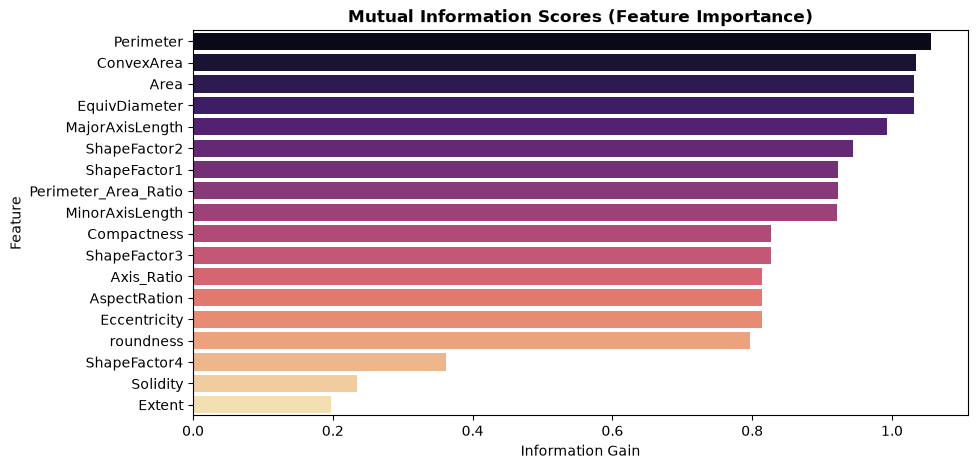

In [45]:
from sklearn.feature_selection import mutual_info_classif

# 1. Feature Engineering: Create custom geometric ratios
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# Perimeter-to-Area Ratio
X_train_eng['Perimeter_Area_Ratio'] = X_train_eng['Perimeter'] / X_train_eng['Area']
X_test_eng['Perimeter_Area_Ratio'] = X_test_eng['Perimeter'] / X_test_eng['Area']

# Major to Minor Axis Ratio
X_train_eng['Axis_Ratio'] = X_train_eng['MajorAxisLength'] / X_train_eng['MinorAxisLength']
X_test_eng['Axis_Ratio'] = X_test_eng['MajorAxisLength'] / X_test_eng['MinorAxisLength']

# 2. Scale Engineered Datasets
scaler_eng = StandardScaler()
X_train_eng_scaled = pd.DataFrame(scaler_eng.fit_transform(X_train_eng), columns=X_train_eng.columns)
X_test_eng_scaled = pd.DataFrame(scaler_eng.transform(X_test_eng), columns=X_test_eng.columns)

# 3. Feature Selection using Mutual Information
mi_scores = mutual_info_classif(X_train_eng_scaled, y_train, random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_eng.columns, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

# Plot Mutual Information Ranking
plt.figure(figsize=(10, 5))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='magma')
plt.title('Mutual Information Scores (Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Information Gain')
plt.show()

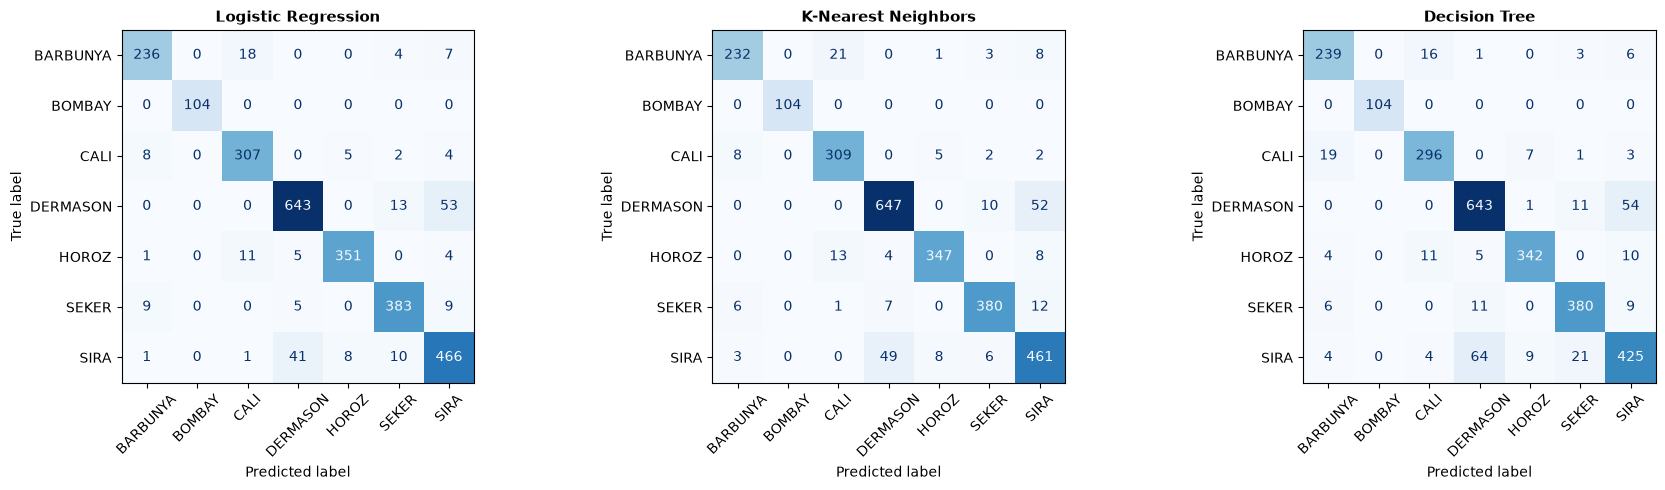

,Model,Accuracy,Precision (Macro),Recall (Macro),Macro F1,Weighted F1
0,Logistic Regression,0.9192,0.9307,0.9300,0.9302,0.9193
1,K-Nearest Neighbors,0.9155,0.9290,0.9256,0.9270,0.9157
2,Decision Tree,0.8966,0.9109,0.9112,0.9109,0.8964


In [46]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# Initialize Baseline Models
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

baseline_metrics = []

# Create subplots for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(baseline_models.items()):
    # Fit & Predict
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    baseline_metrics.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision (Macro)": round(prec_macro, 4),
        "Recall (Macro)": round(rec_macro, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_w, 4)
    })
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{name}", fontsize=11, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display Formal Deliverable 1 Metrics Table
df_deliverable_1 = pd.DataFrame(baseline_metrics)
display(df_deliverable_1)

In [47]:
# 1. Install gradient boosting libraries
!pip install xgboost lightgbm

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels ('SEKER', 'DERMASON', etc.) to integers (0-6) for XGBoost/LightGBM
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Define Advanced Ensemble Models
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
}

# 3. Train and Evaluate
advanced_results = {}

for name, model in advanced_models.items():
    # Train
    model.fit(X_train_scaled, y_train_encoded)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    acc = accuracy_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')
    
    advanced_results[name] = {"Accuracy": acc, "Weighted F1-Score": f1}
    
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f} | Weighted F1-Score: {f1:.4f}\n")

# Combine Baseline and Advanced Results into a single comparison table (Deliverable 3)
all_results = {**baseline_results, **advanced_results}
df_comparison = pd.DataFrame(all_results).T
display(df_comparison.sort_values(by="Weighted F1-Score", ascending=False))

Defaulting to user installation because normal site-packages is not writeable
=== Random Forest ===
Accuracy: 0.9195 | Weighted F1-Score: 0.9194

=== XGBoost ===
Accuracy: 0.9192 | Weighted F1-Score: 0.9192

=== LightGBM ===
Accuracy: 0.9181 | Weighted F1-Score: 0.9181



,Accuracy,Weighted F1-Score
Random Forest,0.919528,0.919448
Logistic Regression,0.919158,0.919290
XGBoost,0.919158,0.919205
LightGBM,0.918051,0.918104
K-Nearest Neighbors,0.915467,0.915652
Decision Tree,0.896641,0.896412


In [48]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Encode class labels for XGBoost / LightGBM compatibility
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Initialize Advanced Models
rf = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42)
xgb = XGBClassifier(n_estimators=150, learning_rate=0.08, max_depth=6, random_state=42)
lgbm = LGBMClassifier(n_estimators=150, learning_rate=0.08, num_leaves=31, random_state=42, verbose=-1)

# 3. Create Proposed Model: Soft Voting Ensemble (Combines RF, XGB, and LightGBM predictions)
ensemble_model = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('lgbm', lgbm)],
    voting='soft'
)

advanced_models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "Voting Ensemble (Proposed)": ensemble_model
}

# 4. Evaluate Advanced Models
advanced_metrics = []

for name, model in advanced_models.items():
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test_encoded, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_test_encoded, y_pred, average='macro')
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_test_encoded, y_pred, average='weighted')
    
    advanced_metrics.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision (Macro)": round(prec_m, 4),
        "Recall (Macro)": round(rec_m, 4),
        "Macro F1": round(f1_m, 4),
        "Weighted F1": round(f1_w, 4)
    })

# Combine Baselines + Advanced into Complete Model Comparison Table (Deliverable 3)
df_all_models = pd.concat([df_deliverable_1, pd.DataFrame(advanced_metrics)], ignore_index=True)
display(df_all_models.sort_values(by="Weighted F1", ascending=False))
# Get Random Forest Feature Importance

feature_importance = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

,Model,Accuracy,Precision (Macro),Recall (Macro),Macro F1,Weighted F1
3,Random Forest,0.9199,0.9333,0.9302,0.9317,0.9199
6,Voting Ensemble (Proposed),0.9199,0.9323,0.9297,0.9309,0.9199
5,LightGBM,0.9195,0.9319,0.9299,0.9308,0.9196
0,Logistic Regression,0.9192,0.9307,0.9300,0.9302,0.9193
4,XGBoost,0.9177,0.9312,0.9286,0.9298,0.9178
1,K-Nearest Neighbors,0.9155,0.9290,0.9256,0.9270,0.9157
2,Decision Tree,0.8966,0.9109,0.9112,0.9109,0.8964


            Feature  Importance
14     ShapeFactor3    0.105351
11      Compactness    0.091631
1         Perimeter    0.091561
12     ShapeFactor1    0.087291
6        ConvexArea    0.080981
2   MajorAxisLength    0.077656
3   MinorAxisLength    0.077542
10        roundness    0.059807
7     EquivDiameter    0.058815
0              Area    0.058123
4      AspectRation    0.055193
5      Eccentricity    0.054784
13     ShapeFactor2    0.041777
15     ShapeFactor4    0.030090
9          Solidity    0.019036
8            Extent    0.010364


In [49]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

In [50]:
df_all_models.to_csv(
    "model_comparison.csv",
    index=False
)

In [51]:
importance_df = pd.read_csv("feature_importance.csv")

In [52]:
print(importance_df.columns)

Index(['Feature', 'Importance'], dtype='str')


In [53]:
import joblib

# 1. Save the fitted StandardScaler object
joblib.dump(scaler, 'scaler.joblib')
print("✅ Saved scaler.joblib")

# 2. Save the fitted LabelEncoder object
joblib.dump(le, 'label_encoder.joblib')
print("✅ Saved label_encoder.joblib")

# 3. Save your best trained model (Voting Ensemble or XGBoost)
joblib.dump(ensemble_model, 'best_dry_bean_model.joblib')
print("✅ Saved best_dry_bean_model.joblib")

✅ Saved scaler.joblib
✅ Saved label_encoder.joblib
✅ Saved best_dry_bean_model.joblib


Defaulting to user installation because normal site-packages is not writeable


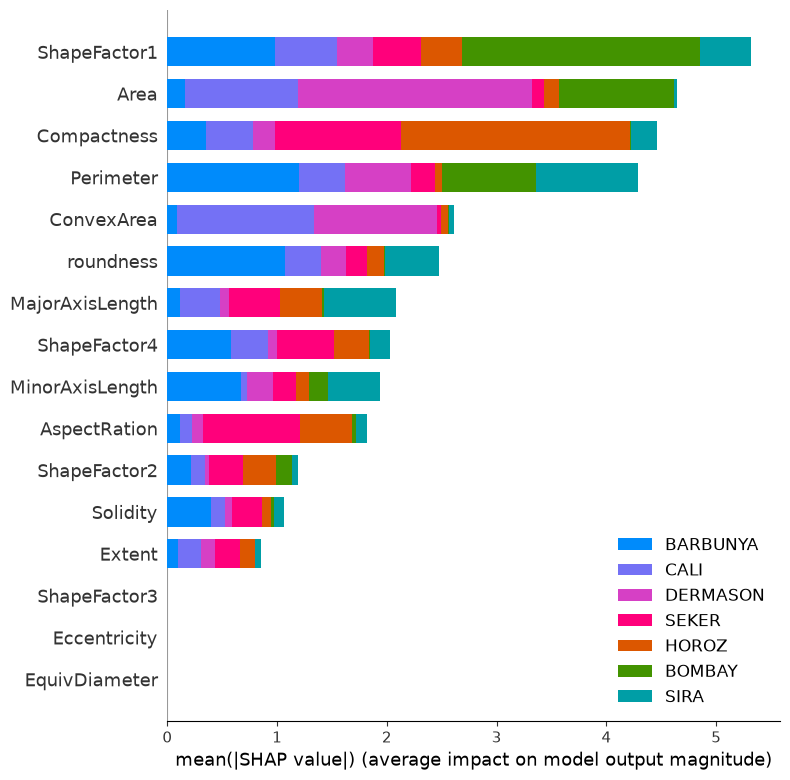

In [54]:
!pip install shap

import shap

# 1. Use TreeExplainer on our trained XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test_scaled)

# 2. Global Feature Importance (SHAP Summary Bar Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, class_names=le.classes_, plot_type="bar")

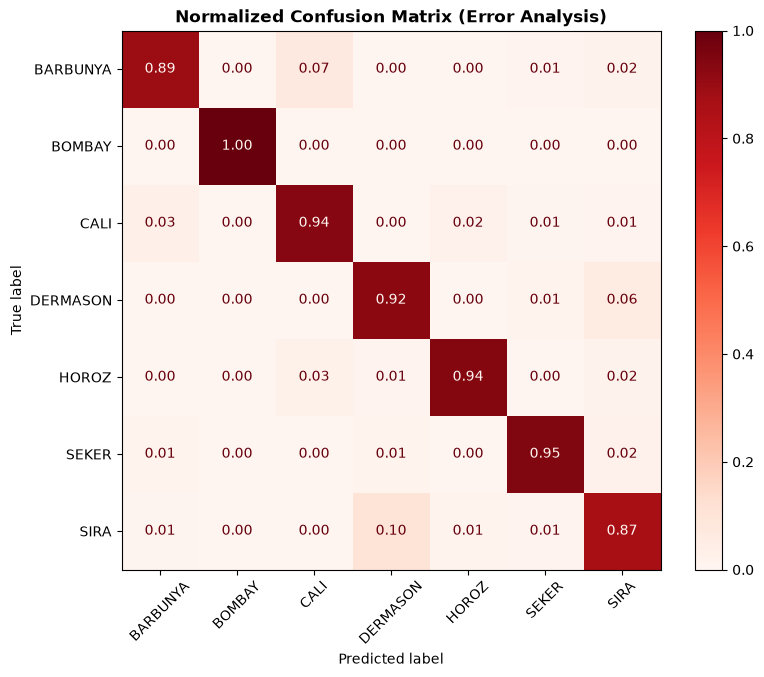

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
best_y_pred = ensemble_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(
    y_test_encoded,
    best_y_pred,
    normalize='true'
)

# Plot
fig, ax = plt.subplots(figsize=(9,7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap='Reds',
    values_format='.2f',
    ax=ax
)

plt.title(
    'Normalized Confusion Matrix (Error Analysis)',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(rotation=45)

# SAVE IMAGE
plt.savefig(
    "confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [56]:
# Create a dataframe of true vs predicted labels for misclassified samples
df_errors = pd.DataFrame({
    'True_Class': le.inverse_transform(y_test_encoded[misclassified_idx]),
    'Predicted_Class': le.inverse_transform(best_y_pred[misclassified_idx])
})

# Display top misclassification pairs
error_pairs = df_errors.groupby(['True_Class', 'Predicted_Class']).size().reset_index(name='Count')
error_pairs = error_pairs.sort_values(by='Count', ascending=False)

print("--- Top 5 Confusion Pairs ---")
display(error_pairs.head(5))

--- Top 5 Confusion Pairs ---


,True_Class,Predicted_Class,Count
20,SIRA,DERMASON,54
10,DERMASON,SIRA,44
0,BARBUNYA,CALI,18
9,DERMASON,SEKER,10
12,HOROZ,CALI,10


In [57]:
import joblib

# Save preprocessors and trained model
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')
joblib.dump(ensemble_model, 'best_dry_bean_model.joblib')

print(" Saved 'scaler.joblib'")
print(" Saved 'label_encoder.joblib'")
print(" Saved 'best_dry_bean_model.joblib'")

 Saved 'scaler.joblib'
 Saved 'label_encoder.joblib'
 Saved 'best_dry_bean_model.joblib'
